In [1]:
# ==============================
# Project 2 - Step 9C
# 生成模拟海外游戏广告投放数据
# ==============================

import numpy as np
import pandas as pd
import itertools

# 固定随机种子，保证每次运行结果一致
np.random.seed(42)

# ------------------------------
# 1. 基础维度
# ------------------------------

countries = ["US", "Brazil"]

channels = [
    "TikTok",
    "Meta",
    "Google_YouTube"
]

creatives = [
    "A_Gunplay",       # 枪战高光
    "B_Squad",         # 小队战术
    "C_Dynamic",       # 动态目标
    "D_Creator",       # 内容创作者 / 真人
    "E_ShortMatch"     # 紧凑体验
]


# ------------------------------
# 2. 国家基础参数
# ------------------------------
# 注意：
# 这些不是现实公司的真实投放数据。
# 只是参考公开行业趋势后，为作品集构建的模拟参数。

country_cfg = {
    "US": {
        "cpm": 13.0,
        "d1": 0.38,
        "d7": 0.18,
        "payer_rate": 0.036,
        "arppu_d7": 10,
        "arppu_d30": 38,
        "spend_range": (2800, 4200)
    },

    "Brazil": {
        "cpm": 4.4,
        "d1": 0.34,
        "d7": 0.15,
        "payer_rate": 0.019,
        "arppu_d7": 4.5,
        "arppu_d30": 18,
        "spend_range": (1800, 3000)
    }
}


# ------------------------------
# 3. 渠道特征
# ------------------------------

channel_cfg = {
    "TikTok": {
        "cpm_mult": 0.90,
        "ctr": 0.030,
        "cvr": 0.28,
        "retention_mult": 0.95,
        "payer_mult": 0.92
    },

    "Meta": {
        "cpm_mult": 1.00,
        "ctr": 0.024,
        "cvr": 0.32,
        "retention_mult": 1.00,
        "payer_mult": 1.02
    },

    "Google_YouTube": {
        "cpm_mult": 1.15,
        "ctr": 0.020,
        "cvr": 0.38,
        "retention_mult": 1.08,
        "payer_mult": 1.15
    }
}


# ------------------------------
# 4. 广告素材特征
# ------------------------------

creative_cfg = {
    "A_Gunplay": {
        "ctr_mult": 1.22,
        "cvr_mult": 1.05,
        "retention_mult": 0.90,
        "payer_mult": 0.86
    },

    "B_Squad": {
        "ctr_mult": 0.98,
        "cvr_mult": 1.00,
        "retention_mult": 1.15,
        "payer_mult": 1.25
    },

    "C_Dynamic": {
        "ctr_mult": 0.92,
        "cvr_mult": 1.12,
        "retention_mult": 1.08,
        "payer_mult": 1.08
    },

    "D_Creator": {
        "ctr_mult": 1.00,
        "cvr_mult": 0.98,
        "retention_mult": 0.98,
        "payer_mult": 0.95
    },

    "E_ShortMatch": {
        "ctr_mult": 1.03,
        "cvr_mult": 1.08,
        "retention_mult": 1.05,
        "payer_mult": 1.05
    }
}


# ------------------------------
# 5. 生成 30 条 Campaign 数据
# ------------------------------

rows = []
campaign_id = 1

for country, channel, creative in itertools.product(
    countries, channels, creatives
):

    country_info = country_cfg[country]
    channel_info = channel_cfg[channel]
    creative_info = creative_cfg[creative]

    # 广告花费
    spend = np.random.uniform(
        country_info["spend_range"][0],
        country_info["spend_range"][1]
    )

    # CPM = 每千次广告展示成本
    cpm = (
        country_info["cpm"]
        * channel_info["cpm_mult"]
        * np.random.uniform(0.95, 1.05)
    )

    # 展示次数
    impressions = int(spend / cpm * 1000)

    # 点击率基础
    ctr = (
        channel_info["ctr"]
        * creative_info["ctr_mult"]
    )

    # Creator 素材在巴西额外增强
    if creative == "D_Creator":
        if country == "Brazil":
            ctr *= 1.42

    ctr *= np.random.uniform(0.94, 1.06)

    # 点击人数
    clicks = int(impressions * ctr)

    # 安装转化率
    cvr = (
        channel_info["cvr"]
        * creative_info["cvr_mult"]
    )

    # 巴西 Creator 素材安装转化额外提升
    if creative == "D_Creator":
        if country == "Brazil":
            cvr *= 1.12
        else:
            cvr *= 0.97

    cvr *= np.random.uniform(0.95, 1.05)

    # 安装人数
    installs = max(1, int(clicks * cvr))

    # D1 留存率
    d1_rate = (
        country_info["d1"]
        * channel_info["retention_mult"]
        * creative_info["retention_mult"]
        * np.random.uniform(0.96, 1.04)
    )

    # D7 留存率
    d7_rate = (
        country_info["d7"]
        * channel_info["retention_mult"]
        * creative_info["retention_mult"]
        * np.random.uniform(0.96, 1.04)
    )

    d1_retained = int(installs * d1_rate)
    d7_retained = int(installs * d7_rate)

    # 30日付费率
    payer_rate = (
        country_info["payer_rate"]
        * channel_info["payer_mult"]
        * creative_info["payer_mult"]
        * np.random.uniform(0.95, 1.05)
    )

    payers_d30 = max(1, int(installs * payer_rate))

    # 付费用户平均付费金额
    arppu_d7 = (
        country_info["arppu_d7"]
        * np.random.uniform(0.92, 1.08)
    )

    arppu_d30 = (
        country_info["arppu_d30"]
        * np.random.uniform(0.92, 1.08)
    )

    # 收入
    revenue_d7 = payers_d30 * arppu_d7
    revenue_d30 = payers_d30 * arppu_d30

    rows.append({
        "campaign_id": campaign_id,
        "country": country,
        "channel": channel,
        "creative": creative,
        "spend": round(spend, 2),
        "impressions": impressions,
        "clicks": clicks,
        "installs": installs,
        "d1_retained": d1_retained,
        "d7_retained": d7_retained,
        "payers_d30": payers_d30,
        "revenue_d7": round(revenue_d7, 2),
        "revenue_d30": round(revenue_d30, 2)
    })

    campaign_id += 1


# ------------------------------
# 6. 转换成 DataFrame
# ------------------------------

campaign_data = pd.DataFrame(rows)


# ------------------------------
# 7. 保存 CSV
# ------------------------------

campaign_data.to_csv(
    "simulated_campaign_data.csv",
    index=False
)


# ------------------------------
# 8. 检查结果
# ------------------------------

print("✅ 模拟 Campaign 数据生成成功")
print(f"数据行数：{len(campaign_data)}")
print(f"数据列数：{len(campaign_data.columns)}")

campaign_data

✅ 模拟 Campaign 数据生成成功
数据行数：30
数据列数：13


,campaign_id,country,channel,creative,spend,impressions,clicks,installs,d1_retained,d7_retained,payers_d30,revenue_d7,revenue_d30
0,1,US,TikTok,A_Gunplay,3324.36,271879,10227,3036,959,454,82,868.04,3166.41
1,2,US,TikTok,B_Squad,3791.30,340360,10570,3057,1239,585,122,1181.79,4654.36
2,3,US,TikTok,C_Dynamic,3404.72,297206,8312,2512,963,458,89,930.61,3219.49
3,4,US,TikTok,D_Creator,3519.93,298093,8456,2274,783,367,74,795.13,2950.75
4,5,US,TikTok,E_ShortMatch,3226.46,287325,9074,2727,1002,489,90,958.94,3288.00
5,6,US,Meta,A_Gunplay,3727.53,292235,8577,2895,965,486,93,995.40,3757.25
6,7,US,Meta,B_Squad,3637.06,268448,6002,1862,784,380,84,809.27,3359.89
7,8,US,Meta,C_Dynamic,3299.45,259488,5758,1989,836,373,82,855.72,2965.79
8,9,US,Meta,D_Creator,2807.73,209374,5149,1602,609,272,55,516.20,2211.42
9,10,US,Meta,E_ShortMatch,3672.62,287368,6731,2282,897,439,89,945.14,3366.96


In [2]:
# ==========================================
# Project 2 - Step 9E
# 检查模拟投放数据的业务逻辑
# ==========================================

analysis_data = campaign_data.copy()


# ------------------------------------------
# 1. 创建汇总函数
# 先汇总原始人数/金额，再计算比例指标
# 这样比直接平均每条 Campaign 的比例更合理
# ------------------------------------------

def make_summary(data, group_cols):

    summary = (
        data.groupby(group_cols, as_index=False)
        .agg(
            spend=("spend", "sum"),
            impressions=("impressions", "sum"),
            clicks=("clicks", "sum"),
            installs=("installs", "sum"),
            d1_retained=("d1_retained", "sum"),
            d7_retained=("d7_retained", "sum"),
            payers_d30=("payers_d30", "sum"),
            revenue_d7=("revenue_d7", "sum"),
            revenue_d30=("revenue_d30", "sum")
        )
    )

    # CTR：点击率
    summary["CTR_%"] = summary["clicks"] / summary["impressions"] * 100

    # CVR：安装转化率
    summary["CVR_%"] = summary["installs"] / summary["clicks"] * 100

    # CPI：每次安装成本
    summary["CPI"] = summary["spend"] / summary["installs"]

    # D1 / D7 留存率
    summary["D1_Retention_%"] = (
        summary["d1_retained"] / summary["installs"] * 100
    )

    summary["D7_Retention_%"] = (
        summary["d7_retained"] / summary["installs"] * 100
    )

    # 30日付费率
    summary["Payer_Rate_%"] = (
        summary["payers_d30"] / summary["installs"] * 100
    )

    # CAC：获取一个30日内付费玩家的成本
    summary["CAC"] = (
        summary["spend"] / summary["payers_d30"]
    )

    # D7 / D30 ROAS：广告支出回报率
    summary["D7_ROAS_%"] = (
        summary["revenue_d7"] / summary["spend"] * 100
    )

    summary["D30_ROAS_%"] = (
        summary["revenue_d30"] / summary["spend"] * 100
    )

    return summary.round(2)


# ------------------------------------------
# 2. 国家整体表现
# ------------------------------------------

country_summary = make_summary(
    analysis_data,
    ["country"]
)

print("===== 1. 国家整体表现 =====")
display(
    country_summary[
        [
            "country",
            "spend",
            "installs",
            "CTR_%",
            "CVR_%",
            "CPI",
            "D7_Retention_%",
            "Payer_Rate_%",
            "CAC",
            "D30_ROAS_%"
        ]
    ]
)


# ------------------------------------------
# 3. 美国 / 巴西 × 广告素材
# ------------------------------------------

country_creative_summary = make_summary(
    analysis_data,
    ["country", "creative"]
)

print("\n===== 2. 各市场 × 广告素材表现 =====")
display(
    country_creative_summary[
        [
            "country",
            "creative",
            "CTR_%",
            "CVR_%",
            "CPI",
            "D7_Retention_%",
            "Payer_Rate_%",
            "D30_ROAS_%"
        ]
    ]
)


# ------------------------------------------
# 4. 自动检查我们预先设定的业务假设
# ------------------------------------------

us_cpi = country_summary.loc[
    country_summary["country"] == "US",
    "CPI"
].iloc[0]

brazil_cpi = country_summary.loc[
    country_summary["country"] == "Brazil",
    "CPI"
].iloc[0]


brazil_creatives = country_creative_summary[
    country_creative_summary["country"] == "Brazil"
]

us_creatives = country_creative_summary[
    country_creative_summary["country"] == "US"
]


brazil_best_ctr = brazil_creatives.loc[
    brazil_creatives["CTR_%"].idxmax(),
    "creative"
]

brazil_lowest_cpi = brazil_creatives.loc[
    brazil_creatives["CPI"].idxmin(),
    "creative"
]

us_best_retention = us_creatives.loc[
    us_creatives["D7_Retention_%"].idxmax(),
    "creative"
]

us_best_roas = us_creatives.loc[
    us_creatives["D30_ROAS_%"].idxmax(),
    "creative"
]


print("\n===== 3. 自动逻辑检查 =====")

print(
    "✅ 美国 CPI 高于巴西"
    if us_cpi > brazil_cpi
    else "⚠️ 美国 CPI 没有高于巴西，需要检查"
)

print(
    f"巴西 CTR 最高素材：{brazil_best_ctr}"
)

print(
    f"巴西 CPI 最低素材：{brazil_lowest_cpi}"
)

print(
    f"美国 D7 留存最高素材：{us_best_retention}"
)

print(
    f"美国 D30 ROAS 最高素材：{us_best_roas}"
)

===== 1. 国家整体表现 =====


,country,spend,installs,CTR_%,CVR_%,CPI,D7_Retention_%,Payer_Rate_%,CAC,D30_ROAS_%
0,Brazil,35228.51,76560,2.78,34.50,0.46,15.47,1.97,23.36,76.31
1,US,50456.38,32844,2.59,32.62,1.54,18.35,3.71,41.43,92.75



===== 2. 各市场 × 广告素材表现 =====


,country,creative,CTR_%,CVR_%,CPI,D7_Retention_%,Payer_Rate_%,D30_ROAS_%
0,Brazil,A_Gunplay,3.15,33.60,0.42,13.84,1.65,70.61
1,Brazil,B_Squad,2.51,31.44,0.54,16.89,2.43,81.90
2,Brazil,C_Dynamic,2.31,35.22,0.55,16.52,2.13,68.13
3,Brazil,D_Creator,3.38,35.47,0.36,14.76,1.80,89.08
4,Brazil,E_ShortMatch,2.48,36.19,0.50,16.19,2.06,70.79
5,US,A_Gunplay,3.12,33.32,1.27,16.25,3.10,93.64
6,US,B_Squad,2.54,31.20,1.61,20.44,4.38,106.56
7,US,C_Dynamic,2.32,33.97,1.61,19.26,3.98,92.16
8,US,D_Creator,2.49,30.46,1.75,17.10,3.44,76.98
9,US,E_ShortMatch,2.50,33.92,1.54,18.93,3.74,92.89



===== 3. 自动逻辑检查 =====
✅ 美国 CPI 高于巴西
巴西 CTR 最高素材：D_Creator
巴西 CPI 最低素材：D_Creator
美国 D7 留存最高素材：B_Squad
美国 D30 ROAS 最高素材：B_Squad


===== Step 10A：国家整体表现 =====


,country,spend,impressions,clicks,installs,CTR_%,CVR_%,CPI,D7_Retention_%,Payer_Rate_%,CAC,D7_ROAS_%,D30_ROAS_%
0,Brazil,35228.51,7989030,221940,76560,2.78,34.50,0.46,15.47,1.97,23.36,19.15,76.31
1,US,50456.38,3882889,100674,32844,2.59,32.62,1.54,18.35,3.71,41.43,24.60,92.75


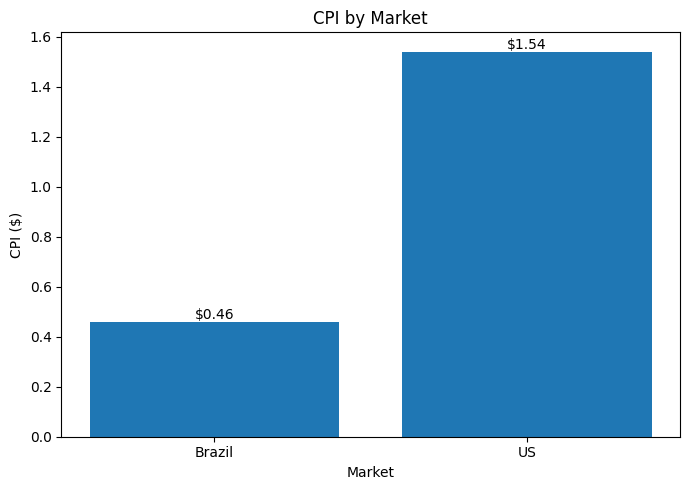

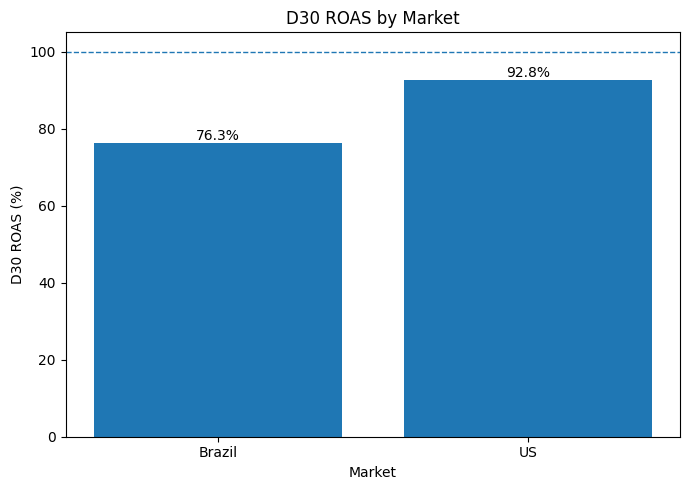


===== Step 10B：各市场 × 渠道表现 =====


,country,channel,spend,installs,CTR_%,CVR_%,CPI,D7_Retention_%,Payer_Rate_%,CAC,D30_ROAS_%
0,Brazil,Google_YouTube,12180.69,22352,2.22,41.26,0.54,16.77,2.26,24.12,74.87
1,Brazil,Meta,11950.68,26081,2.72,34.77,0.46,15.45,1.95,23.52,75.22
2,Brazil,TikTok,11097.14,28127,3.32,30.32,0.39,14.45,1.76,22.42,79.07
3,US,Google_YouTube,16045.22,8608,2.04,39.45,1.86,20.02,4.16,44.82,86.36
4,US,Meta,17144.39,10630,2.45,33.00,1.61,18.34,3.79,42.54,91.35
5,US,TikTok,17266.77,13606,3.12,29.17,1.27,17.29,3.36,37.78,100.07


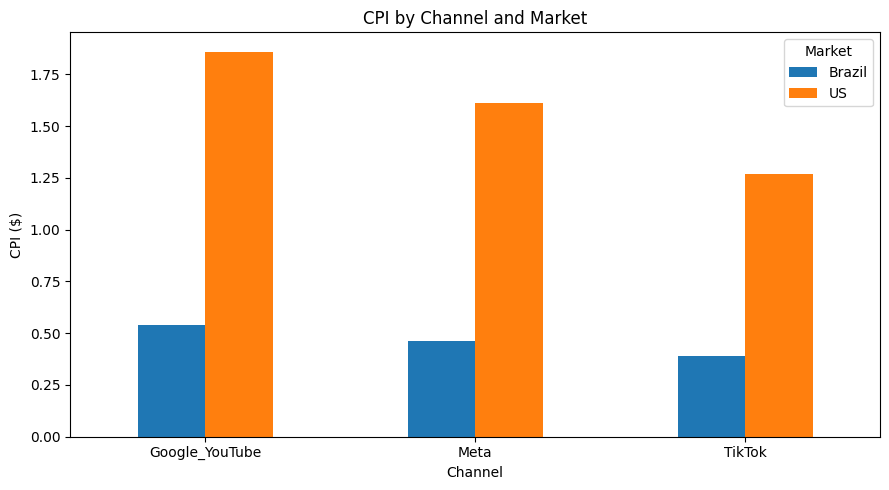

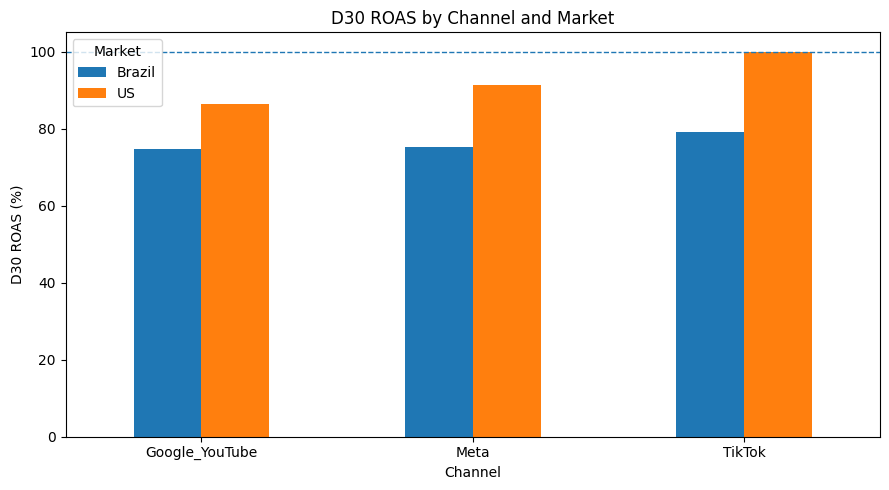


✅ Step 10A + 10B 完成


In [3]:
# ==========================================================
# Project 2 - Step 10A + 10B
# 国家表现 + 渠道表现分析
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# 1. 国家层面汇总
# ----------------------------------------------------------

country_performance = make_summary(
    campaign_data,
    ["country"]
)

print("===== Step 10A：国家整体表现 =====")

display(
    country_performance[
        [
            "country",
            "spend",
            "impressions",
            "clicks",
            "installs",
            "CTR_%",
            "CVR_%",
            "CPI",
            "D7_Retention_%",
            "Payer_Rate_%",
            "CAC",
            "D7_ROAS_%",
            "D30_ROAS_%"
        ]
    ]
)


# ----------------------------------------------------------
# 2. 国家层面：CPI 图
# CPI = 每次安装成本
# ----------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    country_performance["country"],
    country_performance["CPI"]
)

plt.title("CPI by Market")
plt.xlabel("Market")
plt.ylabel("CPI ($)")

for i, value in enumerate(country_performance["CPI"]):
    plt.text(
        i,
        value,
        f"${value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "10A_market_cpi.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ----------------------------------------------------------
# 3. 国家层面：D30 ROAS 图
# D30 ROAS = 30日广告支出回报率
# ----------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    country_performance["country"],
    country_performance["D30_ROAS_%"]
)

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1
)

plt.title("D30 ROAS by Market")
plt.xlabel("Market")
plt.ylabel("D30 ROAS (%)")

for i, value in enumerate(country_performance["D30_ROAS_%"]):
    plt.text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "10A_market_d30_roas.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ----------------------------------------------------------
# 4. 国家 × 渠道汇总
# ----------------------------------------------------------

channel_performance = make_summary(
    campaign_data,
    ["country", "channel"]
)

print("\n===== Step 10B：各市场 × 渠道表现 =====")

display(
    channel_performance[
        [
            "country",
            "channel",
            "spend",
            "installs",
            "CTR_%",
            "CVR_%",
            "CPI",
            "D7_Retention_%",
            "Payer_Rate_%",
            "CAC",
            "D30_ROAS_%"
        ]
    ]
)


# ----------------------------------------------------------
# 5. 渠道 CPI 对比图
# ----------------------------------------------------------

cpi_pivot = channel_performance.pivot(
    index="channel",
    columns="country",
    values="CPI"
)

cpi_pivot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("CPI by Channel and Market")
plt.xlabel("Channel")
plt.ylabel("CPI ($)")
plt.xticks(rotation=0)
plt.legend(title="Market")

plt.tight_layout()
plt.savefig(
    "10B_channel_cpi.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ----------------------------------------------------------
# 6. 渠道 D30 ROAS 对比图
# ----------------------------------------------------------

roas_pivot = channel_performance.pivot(
    index="channel",
    columns="country",
    values="D30_ROAS_%"
)

roas_pivot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1
)

plt.title("D30 ROAS by Channel and Market")
plt.xlabel("Channel")
plt.ylabel("D30 ROAS (%)")
plt.xticks(rotation=0)
plt.legend(title="Market")

plt.tight_layout()
plt.savefig(
    "10B_channel_d30_roas.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


print("\n✅ Step 10A + 10B 完成")

===== Step 10C：整体广告素材表现 =====


,creative,spend,installs,CTR_%,CVR_%,CPI,D7_Retention_%,Payer_Rate_%,CAC,D30_ROAS_%
0,A_Gunplay,16509.23,23436,3.14,33.50,0.70,14.65,2.14,32.89,84.59
1,B_Squad,16645.73,17964,2.52,31.35,0.93,18.17,3.13,29.57,97.28
2,C_Dynamic,17320.52,19706,2.31,34.82,0.88,17.37,2.70,32.50,81.76
3,D_Creator,17366.66,27297,3.13,34.36,0.64,15.22,2.12,30.05,82.54
4,E_ShortMatch,17842.75,21001,2.49,35.40,0.85,17.11,2.62,32.44,84.22



===== 各市场 × 广告素材表现 =====


,country,creative,CTR_%,CVR_%,CPI,D7_Retention_%,Payer_Rate_%,CAC,D30_ROAS_%
0,Brazil,A_Gunplay,3.15,33.60,0.42,13.84,1.65,25.25,70.61
1,Brazil,B_Squad,2.51,31.44,0.54,16.89,2.43,22.38,81.90
2,Brazil,C_Dynamic,2.31,35.22,0.55,16.52,2.13,25.85,68.13
3,Brazil,D_Creator,3.38,35.47,0.36,14.76,1.80,20.25,89.08
4,Brazil,E_ShortMatch,2.48,36.19,0.50,16.19,2.06,24.38,70.79
5,US,A_Gunplay,3.12,33.32,1.27,16.25,3.10,40.90,93.64
6,US,B_Squad,2.54,31.20,1.61,20.44,4.38,36.68,106.56
7,US,C_Dynamic,2.32,33.97,1.61,19.26,3.98,40.43,92.16
8,US,D_Creator,2.49,30.46,1.75,17.10,3.44,51.03,76.98
9,US,E_ShortMatch,2.50,33.92,1.54,18.93,3.74,41.23,92.89


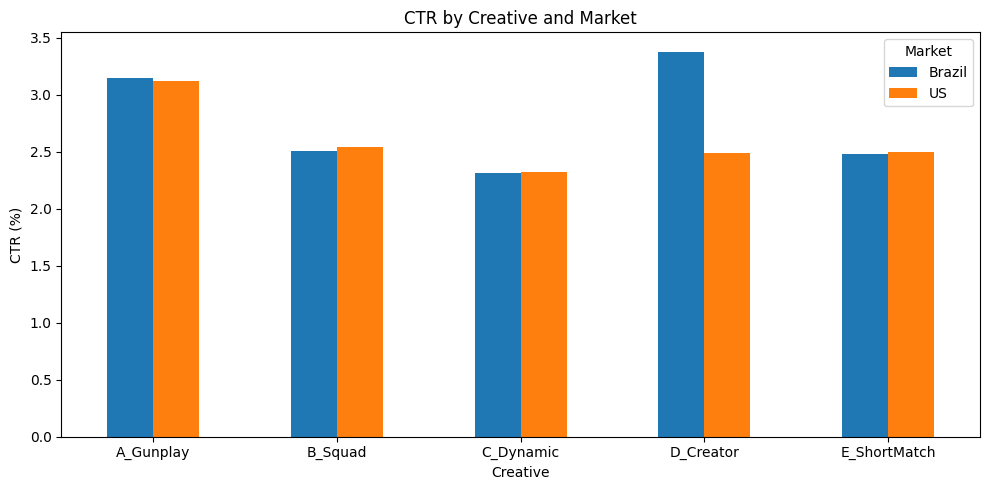

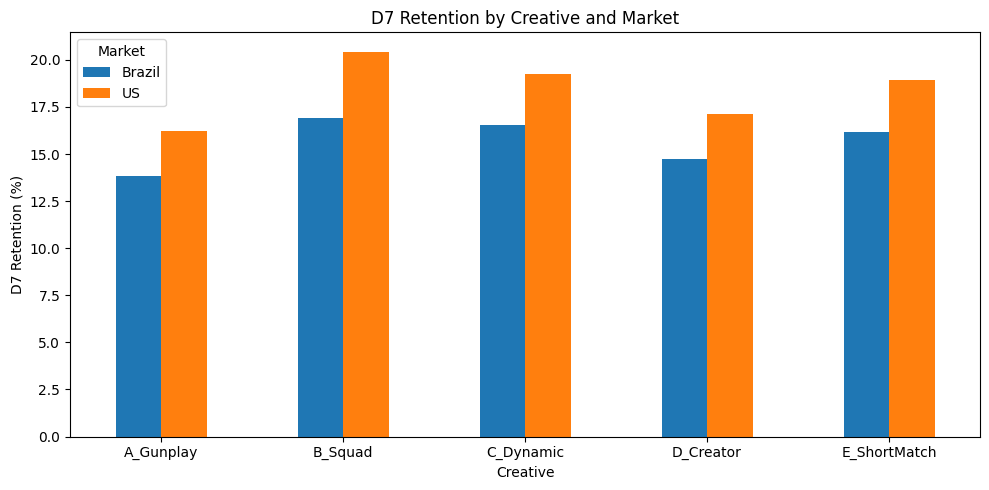

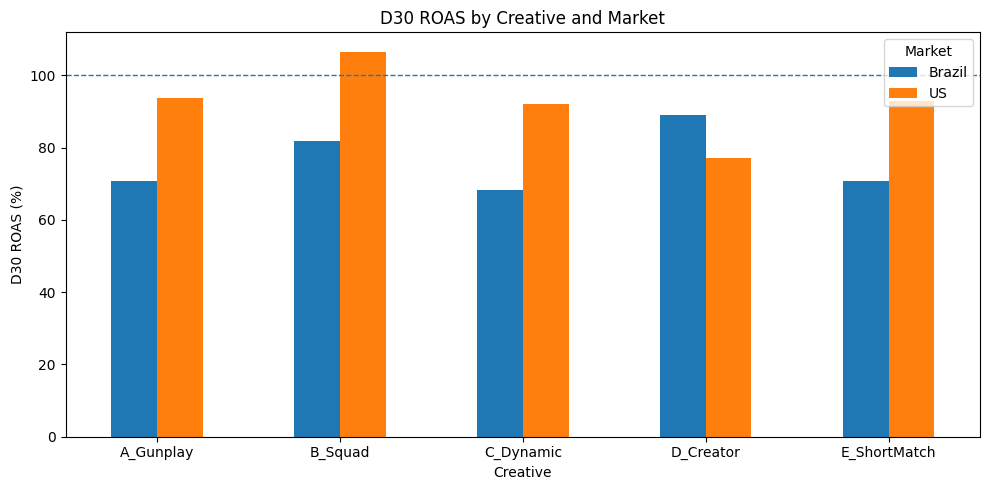


✅ Step 10C 完成


In [4]:
# ==========================================================
# Project 2 - Step 10C
# 广告素材表现分析
# ==========================================================


# ----------------------------------------------------------
# 1. 整体素材表现
# ----------------------------------------------------------

creative_performance = make_summary(
    campaign_data,
    ["creative"]
)

print("===== Step 10C：整体广告素材表现 =====")

display(
    creative_performance[
        [
            "creative",
            "spend",
            "installs",
            "CTR_%",
            "CVR_%",
            "CPI",
            "D7_Retention_%",
            "Payer_Rate_%",
            "CAC",
            "D30_ROAS_%"
        ]
    ]
)


# ----------------------------------------------------------
# 2. 各市场 × 素材表现
# ----------------------------------------------------------

market_creative_performance = make_summary(
    campaign_data,
    ["country", "creative"]
)

print("\n===== 各市场 × 广告素材表现 =====")

display(
    market_creative_performance[
        [
            "country",
            "creative",
            "CTR_%",
            "CVR_%",
            "CPI",
            "D7_Retention_%",
            "Payer_Rate_%",
            "CAC",
            "D30_ROAS_%"
        ]
    ]
)


# ----------------------------------------------------------
# 3. CTR 对比
# ----------------------------------------------------------

ctr_pivot = market_creative_performance.pivot(
    index="creative",
    columns="country",
    values="CTR_%"
)

ctr_pivot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("CTR by Creative and Market")
plt.xlabel("Creative")
plt.ylabel("CTR (%)")
plt.xticks(rotation=0)
plt.legend(title="Market")

plt.tight_layout()

plt.savefig(
    "10C_creative_ctr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------------------------------------
# 4. D7留存率对比
# ----------------------------------------------------------

retention_pivot = market_creative_performance.pivot(
    index="creative",
    columns="country",
    values="D7_Retention_%"
)

retention_pivot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("D7 Retention by Creative and Market")
plt.xlabel("Creative")
plt.ylabel("D7 Retention (%)")
plt.xticks(rotation=0)
plt.legend(title="Market")

plt.tight_layout()

plt.savefig(
    "10C_creative_d7_retention.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------------------------------------
# 5. D30 ROAS 对比
# ----------------------------------------------------------

creative_roas_pivot = market_creative_performance.pivot(
    index="creative",
    columns="country",
    values="D30_ROAS_%"
)

creative_roas_pivot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1
)

plt.title("D30 ROAS by Creative and Market")
plt.xlabel("Creative")
plt.ylabel("D30 ROAS (%)")
plt.xticks(rotation=0)
plt.legend(title="Market")

plt.tight_layout()

plt.savefig(
    "10C_creative_d30_roas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\n✅ Step 10C 完成")

In [5]:
# ==========================================================
# Project 2 - Step 10D
# Campaign 组合表现排名
# ==========================================================

campaign_ranking = make_summary(
    campaign_data,
    ["country", "channel", "creative"]
)

# 按 D30 ROAS 从高到低排序
campaign_ranking = campaign_ranking.sort_values(
    by="D30_ROAS_%",
    ascending=False
).reset_index(drop=True)


print("===== D30 ROAS 最高的 10 个 Campaign =====")

display(
    campaign_ranking[
        [
            "country",
            "channel",
            "creative",
            "spend",
            "installs",
            "CTR_%",
            "CPI",
            "D7_Retention_%",
            "Payer_Rate_%",
            "CAC",
            "D30_ROAS_%"
        ]
    ].head(10)
)


print("\n===== D30 ROAS 最低的 10 个 Campaign =====")

display(
    campaign_ranking[
        [
            "country",
            "channel",
            "creative",
            "spend",
            "installs",
            "CTR_%",
            "CPI",
            "D7_Retention_%",
            "Payer_Rate_%",
            "CAC",
            "D30_ROAS_%"
        ]
    ].tail(10)
)


# ----------------------------------------------------------
# 标记 Campaign 建议
# 这里只做初步分类，不直接等同于最终预算决策
# ----------------------------------------------------------

def classify_campaign(row):

    if (
        row["D30_ROAS_%"] >= 100
        and row["D7_Retention_%"] >= 18
    ):
        return "Scale Candidate"

    elif row["D30_ROAS_%"] >= 85:
        return "Keep / Optimize"

    elif row["D30_ROAS_%"] >= 70:
        return "Test Carefully"

    else:
        return "Reduce / Pause"


campaign_ranking["recommendation"] = campaign_ranking.apply(
    classify_campaign,
    axis=1
)


print("\n===== Campaign 初步分类 =====")

display(
    campaign_ranking[
        [
            "country",
            "channel",
            "creative",
            "CPI",
            "D7_Retention_%",
            "D30_ROAS_%",
            "recommendation"
        ]
    ]
)


# 保存结果
campaign_ranking.to_csv(
    "campaign_performance_ranking.csv",
    index=False
)

print("\n✅ Step 10D 完成")

===== D30 ROAS 最高的 10 个 Campaign =====


,country,channel,creative,spend,installs,CTR_%,CPI,D7_Retention_%,Payer_Rate_%,CAC,D30_ROAS_%
0,US,TikTok,B_Squad,3791.30,3057,3.11,1.24,19.14,3.99,31.08,122.76
1,US,Google_YouTube,B_Squad,2951.05,1538,1.99,1.92,23.08,5.01,38.33,103.21
2,US,TikTok,E_ShortMatch,3226.46,2727,3.16,1.18,17.93,3.30,35.85,101.91
3,US,Meta,A_Gunplay,3727.53,2895,2.93,1.29,16.79,3.21,40.08,100.80
4,US,TikTok,A_Gunplay,3324.36,3036,3.76,1.09,14.95,2.70,40.54,95.25
5,Brazil,TikTok,D_Creator,2560.24,8288,4.05,0.31,13.61,1.58,19.54,94.72
6,US,TikTok,C_Dynamic,3404.72,2512,2.80,1.36,18.23,3.54,38.26,94.56
7,US,Meta,B_Squad,3637.06,1862,2.24,1.95,20.41,4.51,43.30,92.38
8,US,Google_YouTube,C_Dynamic,3120.32,1606,1.79,1.94,21.48,4.48,43.34,91.94
9,US,Meta,E_ShortMatch,3672.62,2282,2.34,1.61,19.24,3.90,41.27,91.68



===== D30 ROAS 最低的 10 个 Campaign =====


,country,channel,creative,spend,installs,CTR_%,CPI,D7_Retention_%,Payer_Rate_%,CAC,D30_ROAS_%
20,Brazil,Google_YouTube,E_ShortMatch,2988.06,5385,2.06,0.55,17.27,2.34,23.71,73.40
21,Brazil,Google_YouTube,C_Dynamic,2244.19,3810,1.93,0.59,18.14,2.44,24.13,73.22
22,Brazil,Google_YouTube,B_Squad,2034.29,2716,1.91,0.75,18.11,2.84,26.42,72.65
23,Brazil,TikTok,C_Dynamic,2387.34,4905,2.67,0.49,15.07,1.92,25.40,72.37
24,Brazil,TikTok,E_ShortMatch,1819.91,4208,2.99,0.43,15.19,1.81,23.95,70.81
25,Brazil,TikTok,A_Gunplay,2187.84,5995,3.75,0.36,13.29,1.45,25.15,69.30
26,US,Google_YouTube,D_Creator,3061.20,1474,2.01,2.08,18.72,3.73,55.66,67.48
27,Brazil,Meta,E_ShortMatch,2190.48,4372,2.52,0.50,15.83,1.94,25.77,67.22
28,Brazil,Google_YouTube,A_Gunplay,2092.79,3944,2.41,0.53,14.91,1.88,28.28,63.57
29,Brazil,Meta,C_Dynamic,2864.50,4884,2.25,0.59,16.71,2.11,27.81,60.60



===== Campaign 初步分类 =====


,country,channel,creative,CPI,D7_Retention_%,D30_ROAS_%,recommendation
0,US,TikTok,B_Squad,1.24,19.14,122.76,Scale Candidate
1,US,Google_YouTube,B_Squad,1.92,23.08,103.21,Scale Candidate
2,US,TikTok,E_ShortMatch,1.18,17.93,101.91,Keep / Optimize
3,US,Meta,A_Gunplay,1.29,16.79,100.80,Keep / Optimize
4,US,TikTok,A_Gunplay,1.09,14.95,95.25,Keep / Optimize
5,Brazil,TikTok,D_Creator,0.31,13.61,94.72,Keep / Optimize
6,US,TikTok,C_Dynamic,1.36,18.23,94.56,Keep / Optimize
7,US,Meta,B_Squad,1.95,20.41,92.38,Keep / Optimize
8,US,Google_YouTube,C_Dynamic,1.94,21.48,91.94,Keep / Optimize
9,US,Meta,E_ShortMatch,1.61,19.24,91.68,Keep / Optimize



✅ Step 10D 完成


===== 下一轮 $100,000 Budget Allocation =====


,country,channel,creative,old_spend,new_budget,D7_Retention_%,D30_ROAS_%,reason
0,US,TikTok,B_Squad,3791.30,15000,19.14,122.76,Top-performing campaign; prioritize scaling
1,US,Google_YouTube,B_Squad,2951.05,10000,23.08,103.21,High retention and payer quality
2,US,TikTok,E_ShortMatch,3226.46,8000,17.93,101.91,D30 ROAS above 100%; continue scaling
3,US,Meta,A_Gunplay,3727.53,8000,16.79,100.80,D30 ROAS above 100%; stable acquisition
4,US,TikTok,C_Dynamic,3404.72,7000,18.23,94.56,Strong quality; continue optimization
5,US,Meta,B_Squad,3637.06,7000,20.41,92.38,Strong retention; continue testing
6,US,TikTok,A_Gunplay,3324.36,5000,14.95,95.25,Efficient acquisition but weaker downstream qu...
7,US,Google_YouTube,C_Dynamic,3120.32,5000,21.48,91.94,High-quality users but acquisition cost needs ...
8,US,Meta,E_ShortMatch,3672.62,3000,19.24,91.68,Maintain and monitor
9,US,Testing_Reserve,New_Squad_Variants,0.00,2000,NaN,NaN,Test new squad-focused creative variants



===== 市场预算分配 =====


,country,new_budget,share_%
0,Brazil,30000,30.0
1,US,70000,70.0



===== 渠道预算分配 =====


,channel,new_budget,share_%
3,TikTok,48000,48.0
1,Meta,26000,26.0
0,Google_YouTube,19000,19.0
2,Testing_Reserve,7000,7.0


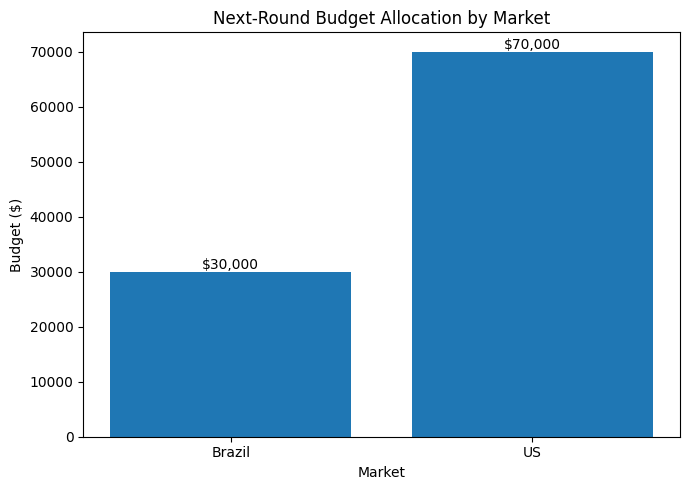


✅ Step 11 Budget Allocation 完成
总预算：$100,000


In [6]:
# ==========================================================
# Project 2 - Step 11
# 下一轮 $100,000 广告预算重新分配
# ==========================================================

import pandas as pd
import numpy as np


# ----------------------------------------------------------
# 1. 建立下一轮预算方案
# ----------------------------------------------------------

budget_plan = pd.DataFrame([

    # =========================
    # US - $70,000
    # =========================

    ["US", "TikTok", "B_Squad", 15000,
     "Top-performing campaign; prioritize scaling"],

    ["US", "Google_YouTube", "B_Squad", 10000,
     "High retention and payer quality"],

    ["US", "TikTok", "E_ShortMatch", 8000,
     "D30 ROAS above 100%; continue scaling"],

    ["US", "Meta", "A_Gunplay", 8000,
     "D30 ROAS above 100%; stable acquisition"],

    ["US", "TikTok", "C_Dynamic", 7000,
     "Strong quality; continue optimization"],

    ["US", "Meta", "B_Squad", 7000,
     "Strong retention; continue testing"],

    ["US", "TikTok", "A_Gunplay", 5000,
     "Efficient acquisition but weaker downstream quality"],

    ["US", "Google_YouTube", "C_Dynamic", 5000,
     "High-quality users but acquisition cost needs optimization"],

    ["US", "Meta", "E_ShortMatch", 3000,
     "Maintain and monitor"],

    ["US", "Testing_Reserve", "New_Squad_Variants", 2000,
     "Test new squad-focused creative variants"],


    # =========================
    # Brazil - $30,000
    # =========================

    ["Brazil", "TikTok", "D_Creator", 10000,
     "Best Brazil campaign; strong CTR and low CPI"],

    ["Brazil", "Meta", "B_Squad", 5000,
     "Strong user quality and relatively high ROAS"],

    ["Brazil", "Google_YouTube", "D_Creator", 4000,
     "Continue testing creator format across channels"],

    ["Brazil", "Meta", "D_Creator", 3000,
     "Maintain creator-led acquisition"],

    ["Brazil", "TikTok", "B_Squad", 3000,
     "Continue squad-message testing"],

    ["Brazil", "Testing_Reserve", "Local_Creator_Variants", 5000,
     "Test new Brazilian creator and localized variants"]

], columns=[
    "country",
    "channel",
    "creative",
    "new_budget",
    "reason"
])


# ----------------------------------------------------------
# 2. 加入上一轮 Campaign 数据
# ----------------------------------------------------------

historical = campaign_ranking[
    [
        "country",
        "channel",
        "creative",
        "spend",
        "CPI",
        "D7_Retention_%",
        "D30_ROAS_%"
    ]
].copy()


budget_plan = budget_plan.merge(
    historical,
    on=["country", "channel", "creative"],
    how="left"
)


budget_plan.rename(
    columns={"spend": "old_spend"},
    inplace=True
)


budget_plan["old_spend"] = budget_plan["old_spend"].fillna(0)


# ----------------------------------------------------------
# 3. 计算预算变化
# ----------------------------------------------------------

budget_plan["budget_change"] = (
    budget_plan["new_budget"]
    - budget_plan["old_spend"]
)


budget_plan["budget_change_%"] = np.where(
    budget_plan["old_spend"] > 0,
    budget_plan["budget_change"]
    / budget_plan["old_spend"]
    * 100,
    np.nan
)


# ----------------------------------------------------------
# 4. 显示完整预算方案
# ----------------------------------------------------------

print("===== 下一轮 $100,000 Budget Allocation =====")

display(
    budget_plan[
        [
            "country",
            "channel",
            "creative",
            "old_spend",
            "new_budget",
            "D7_Retention_%",
            "D30_ROAS_%",
            "reason"
        ]
    ].round(2)
)


# ----------------------------------------------------------
# 5. 市场层面预算
# ----------------------------------------------------------

market_budget = (
    budget_plan
    .groupby("country", as_index=False)
    ["new_budget"]
    .sum()
)

market_budget["share_%"] = (
    market_budget["new_budget"]
    / market_budget["new_budget"].sum()
    * 100
)


print("\n===== 市场预算分配 =====")

display(
    market_budget.round(2)
)


# ----------------------------------------------------------
# 6. 渠道层面预算
# ----------------------------------------------------------

channel_budget = (
    budget_plan
    .groupby("channel", as_index=False)
    ["new_budget"]
    .sum()
    .sort_values(
        "new_budget",
        ascending=False
    )
)

channel_budget["share_%"] = (
    channel_budget["new_budget"]
    / channel_budget["new_budget"].sum()
    * 100
)


print("\n===== 渠道预算分配 =====")

display(
    channel_budget.round(2)
)


# ----------------------------------------------------------
# 7. 画市场预算图
# ----------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    market_budget["country"],
    market_budget["new_budget"]
)

plt.title("Next-Round Budget Allocation by Market")
plt.xlabel("Market")
plt.ylabel("Budget ($)")


for i, value in enumerate(market_budget["new_budget"]):

    plt.text(
        i,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.savefig(
    "11_budget_by_market.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------------------------------------
# 8. 保存预算文件
# ----------------------------------------------------------

budget_plan.to_csv(
    "next_round_budget_allocation.csv",
    index=False
)


print("\n✅ Step 11 Budget Allocation 完成")
print(
    f"总预算：${budget_plan['new_budget'].sum():,.0f}"
)

In [7]:
# ==========================================================
# Project 2 - Step 12A
# 整理并打包当前全部分析成果
# ==========================================================

import os
import shutil
import pandas as pd


# ----------------------------------------------------------
# 1. 创建导出文件夹
# ----------------------------------------------------------

export_root = "project2_export"

data_dir = os.path.join(export_root, "data")
table_dir = os.path.join(export_root, "outputs", "tables")
chart_dir = os.path.join(export_root, "outputs", "charts")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(table_dir, exist_ok=True)
os.makedirs(chart_dir, exist_ok=True)


# ----------------------------------------------------------
# 2. 保存原始模拟数据
# ----------------------------------------------------------

campaign_data.to_csv(
    os.path.join(
        data_dir,
        "simulated_campaign_data.csv"
    ),
    index=False
)


# ----------------------------------------------------------
# 3. 保存主要分析表
# ----------------------------------------------------------

country_performance.to_csv(
    os.path.join(
        table_dir,
        "country_performance.csv"
    ),
    index=False
)

channel_performance.to_csv(
    os.path.join(
        table_dir,
        "channel_performance.csv"
    ),
    index=False
)

creative_performance.to_csv(
    os.path.join(
        table_dir,
        "creative_performance.csv"
    ),
    index=False
)

market_creative_performance.to_csv(
    os.path.join(
        table_dir,
        "market_creative_performance.csv"
    ),
    index=False
)

campaign_ranking.to_csv(
    os.path.join(
        table_dir,
        "campaign_performance_ranking.csv"
    ),
    index=False
)

budget_plan.to_csv(
    os.path.join(
        table_dir,
        "next_round_budget_allocation.csv"
    ),
    index=False
)

market_budget.to_csv(
    os.path.join(
        table_dir,
        "market_budget_allocation.csv"
    ),
    index=False
)

channel_budget.to_csv(
    os.path.join(
        table_dir,
        "channel_budget_allocation.csv"
    ),
    index=False
)


# ----------------------------------------------------------
# 4. 复制已经生成的高清图表
# ----------------------------------------------------------

chart_files = [
    "10A_market_cpi.png",
    "10A_market_d30_roas.png",
    "10B_channel_cpi.png",
    "10B_channel_d30_roas.png",
    "10C_creative_ctr.png",
    "10C_creative_d7_retention.png",
    "10C_creative_d30_roas.png",
    "11_budget_by_market.png"
]

copied_charts = []

for filename in chart_files:

    if os.path.exists(filename):

        shutil.copy(
            filename,
            os.path.join(chart_dir, filename)
        )

        copied_charts.append(filename)


# ----------------------------------------------------------
# 5. 创建数据说明文件
# ----------------------------------------------------------

notes = """
Project 2 - Global Mobile Game Launch & Marketing Strategy

DATA STATUS

1. simulated_campaign_data.csv
   Synthetic / simulated campaign dataset created for portfolio analysis.

2. Campaign-level spend, impressions, clicks, installs, retention,
   payer and revenue figures are NOT real company internal data.

3. Public market and competitor research used elsewhere in the project
   comes from publicly available third-party or official sources.

4. Synthetic campaign parameters were designed to reflect plausible
   business patterns identified in public industry research.

5. The dataset must never be presented as real advertising data
   from PUBG MOBILE, Free Fire, Call of Duty Mobile, Delta Force,
   or any other company.
"""

with open(
    os.path.join(export_root, "DATA_NOTES.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(notes)


# ----------------------------------------------------------
# 6. 打包 ZIP
# ----------------------------------------------------------

shutil.make_archive(
    "Project2_Analysis_Assets",
    "zip",
    export_root
)


# ----------------------------------------------------------
# 7. 检查
# ----------------------------------------------------------

print("✅ Project 2 分析资产整理完成")
print()
print("已保存数据文件：")
print("- simulated_campaign_data.csv")

print()
print("已保存分析表：")
print("- country_performance.csv")
print("- channel_performance.csv")
print("- creative_performance.csv")
print("- market_creative_performance.csv")
print("- campaign_performance_ranking.csv")
print("- next_round_budget_allocation.csv")
print("- market_budget_allocation.csv")
print("- channel_budget_allocation.csv")

print()
print(f"已保存图表数量：{len(copied_charts)}")
for chart in copied_charts:
    print("-", chart)

print()
print("✅ ZIP 文件：Project2_Analysis_Assets.zip")

✅ Project 2 分析资产整理完成

已保存数据文件：
- simulated_campaign_data.csv

已保存分析表：
- country_performance.csv
- channel_performance.csv
- creative_performance.csv
- market_creative_performance.csv
- campaign_performance_ranking.csv
- next_round_budget_allocation.csv
- market_budget_allocation.csv
- channel_budget_allocation.csv

已保存图表数量：8
- 10A_market_cpi.png
- 10A_market_d30_roas.png
- 10B_channel_cpi.png
- 10B_channel_d30_roas.png
- 10C_creative_ctr.png
- 10C_creative_d7_retention.png
- 10C_creative_d30_roas.png
- 11_budget_by_market.png

✅ ZIP 文件：Project2_Analysis_Assets.zip
